## Análisis de Clústeres Biosintéticos de Tiopéptidos
**Autor:** Fernanda Rivas Romero

---



## **METODOLOGÍA EMPLEADA HASTA AHORA**
### ***1. Búsqueda de tiopéptidos***
Dentro de la búsqueda de la literatura, la variedad de tiopéptidos es muy amplia dentro de los subgrupos denominados series. En este caso, la series d-e son las que se encuentran mayor caracterizadas, a diferencia de las series a, b y c. Es por ello que se realizó la búsqueda de tiopéptidos de todas las series para conocer que tan bien se encuentran caracterizados, esta caracterización enfocada en las seis enzimas indispensables para su macrociclización (YcaO, Ocin-Thiflike, FMN-dehydrogenase, dehydratase glutamylation and elimination domains, and [4 + 2]-macrocyclization), universalmente conservadas, a diferencia de las enzimas de modificación post-traduccional, las cuales varían significativamentre entre las series, e incluso dentro de los miembros de una misma serie. 

Durante la búsqueda las enzimas indispensables para la macrociclización, hay algunas que ya se encuentran en MIBiG con su número de acesión en el NCBI (ACN...) o su ID de proteína hipotética (PY...) Se seleccionaron algunos tiopéptidos que tienen ya caracterizadas sus enzimas de macrociclización y en algunos casos su vía de síntesis (tabla 1). Cabe mencionar que con todos los tiopéptidos caracterizados son a partir de un organizmo de la clase Actinomicetes. 

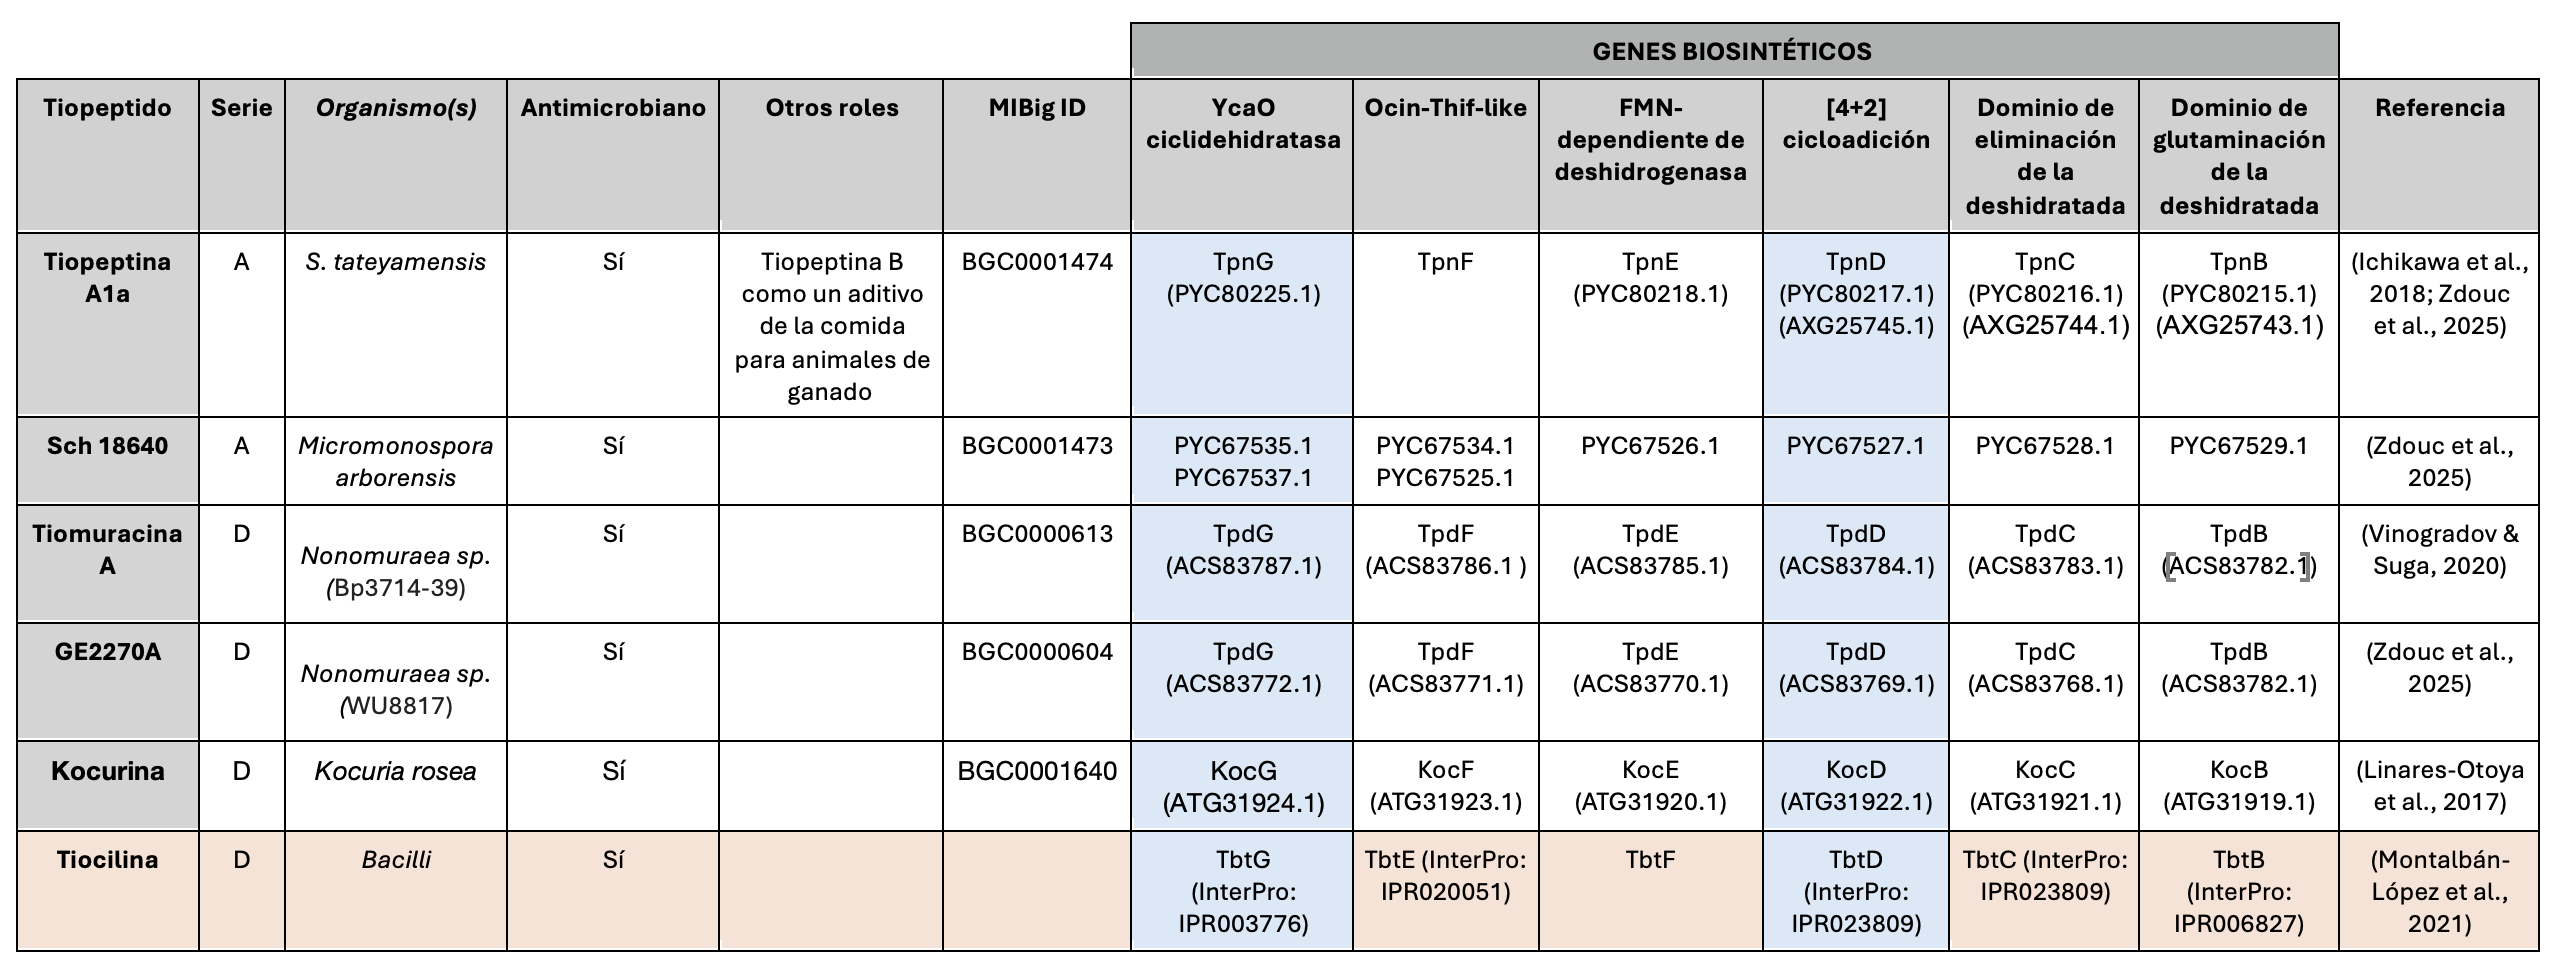
*Tabla 1. Metadatos de tiopéptidos de distintas series con sus genes biosintéticos indispensables para la macrociclización.*

Sin embargo, para poder ampliar más nuestra taxonomía y no sólo buscar en los grupos que ya se han caracterizado anteriormente, principalmente en los Actinomicetos, se utilizó la base de datos InterPro para la búsqueda de dominios de la YcaO y la [4+2] cicloadición. En el caso de la YcaO porque está universalmente conservada en todas las series y nos permite poder ampliar nuestro rango taxonómico para explorar otros grupos. La [4+2] cicloadición por ser reportada como una enzima de definición de clase de los tiopéptidos. En la tabla 1 esta la tiocilina (marcada con naranja), con sus IDs correspontientes a InterPro.


### ***2. INTERPRO***
Antes de utilizar BLASTp con los IDs para tiocilina para TbtG (YcaO) y TbTD ([4+2] cicloadición) se hizo la selección de los organismos que se emplearían para buscar la homología en BLASTp de las enzimas seleccionadas. Para ambas se hizo la selección del taxón de la clase Bacilli. 

Se descargaron los FASTA de todas las secuencias de esa clase y se hizo un filtrado para la búsqueda de homólogos de 5 especies. El scipt del filtrado y los candidatos seleccionados se encuentran en `YcaO-selection-blastp.R` y `cicloadicion-selection-blastp.R`

Con estas secuencias seleccionadas se hizo el BLASTp.

> *Nota: todas las secuencias descargadas antes de hacer el filtrado estan en: `raw-data/YcaO-selection/YcaO-all-PF02624.fasta`; y los candidatos ya filtrados: `raw-data/YcaO-selection/YcaO-candidates-PF02624.fasta`. Para la [4+2] cicloadicion:*

### ***3. BLAST***
La búsqueda de estas secuencias de proteínas homólogas en otros organismos se puede realizar a través de BLASTp (protein blast), donde los parámetros elegidos son:
1. **Choose Search Set:** ClusteredNR. Se elige esta base de datos que incluye un subset reducido pero representativo de la base de datos nr (NON-REDUNDANT). Ofrece una cobertura taxonómica más amplia ya que la búsqueda de secuencias lo hace también en homóloglos distantes. Además, su velocidad de búsqueda es más rápida que los non-redundant
2. **Program Selection:** PSI-BLAST. Se elige ya que realiza una búsqueda iterativa para una matriz de puntuación específica por posición (PSSM) para identificar parientes distantes en una familia de proteínas. Funciona si el tiopéptido es altamente divergente entre especies y blastp falla en la selección de homólogos distantes.

##### ***Parámetros de filtrado*** 
Para ahorrar tiempo de descarga, cuando PSI-BLAST arroja los resultados, en el apartado de "Filter Results" se hizo el filtrado para los parámetros de "Percent Identity" y "Query Coverage". Para el primero de 40-100, y para el segundo del 80-100. 

Una vez con el filtrado se pueden descargar todas las secuencias (select all) en formato FASTA (cluster) para obtener un formato multifasta de todas las secuencias a analizar.

> *Nota: en BLAST hay "Cluster Composition", donde se engloban las secuencias de organismos homólogos a la proteína que estamos buscando, sin embargo, cuando se hace la descarga de los formatos FASTA, si el cluster esta compuesto de cuatro organismos, sólo se descarga uno, el más representativo, es decir, BLAST selecciona la secuencia más completa, con mejor cobertura o anotación dentro de este cluster. Esto evita que en el análisis MSA dominen secuencias casi idénticas (cepas o aislados sobre representados en la base de datos)*

### ***4. Generación de árboles filogenéticos de los tiopéptidos seleccionados***

Con los resultados del BLAST para las enzimas YcaO y [4+2] cicloadición se realizaron árboles filogenéticos para ver la distribución los clados homólogos con las secuencias consenso. Los pasos realizados están en el archivo `MSA_arboles-filo.R`

##### ***Parámetros utilizados***

1. **Alineamiento múltiple:** se empleó MUSCLE debido a la precisión para conjuntos de datos pequeños-medianos (menos de 200-500 secuencias)
2. **Curación del alineamiento:** se empleó ClipKit debido a que es una herrmienta que preserva la precisión filogenética y la longitud de las ramas y no es tan agresivo como otro métodos de curación del alineamiento
3. **Árbol filogenético:** se empleó IQTree, un enfoque de Máxima Verosimilitud (ML) que busca la mejor combinación y selección automática de los modelos, velocidad y rigor estadístico. Además, implementa UFBoot (aproximación a bootstrap) que calcula el soporte de ramas de manera más rápida y con menor sesgo

### ***Anexo de conjuntos de genes biosintéticos (CGB)***
Este apartado es para poner las fotografías y referencias de donde se obtuvieron los nombres de las proteínas que conforman las seis enzimas indispensables para la macrociclización 

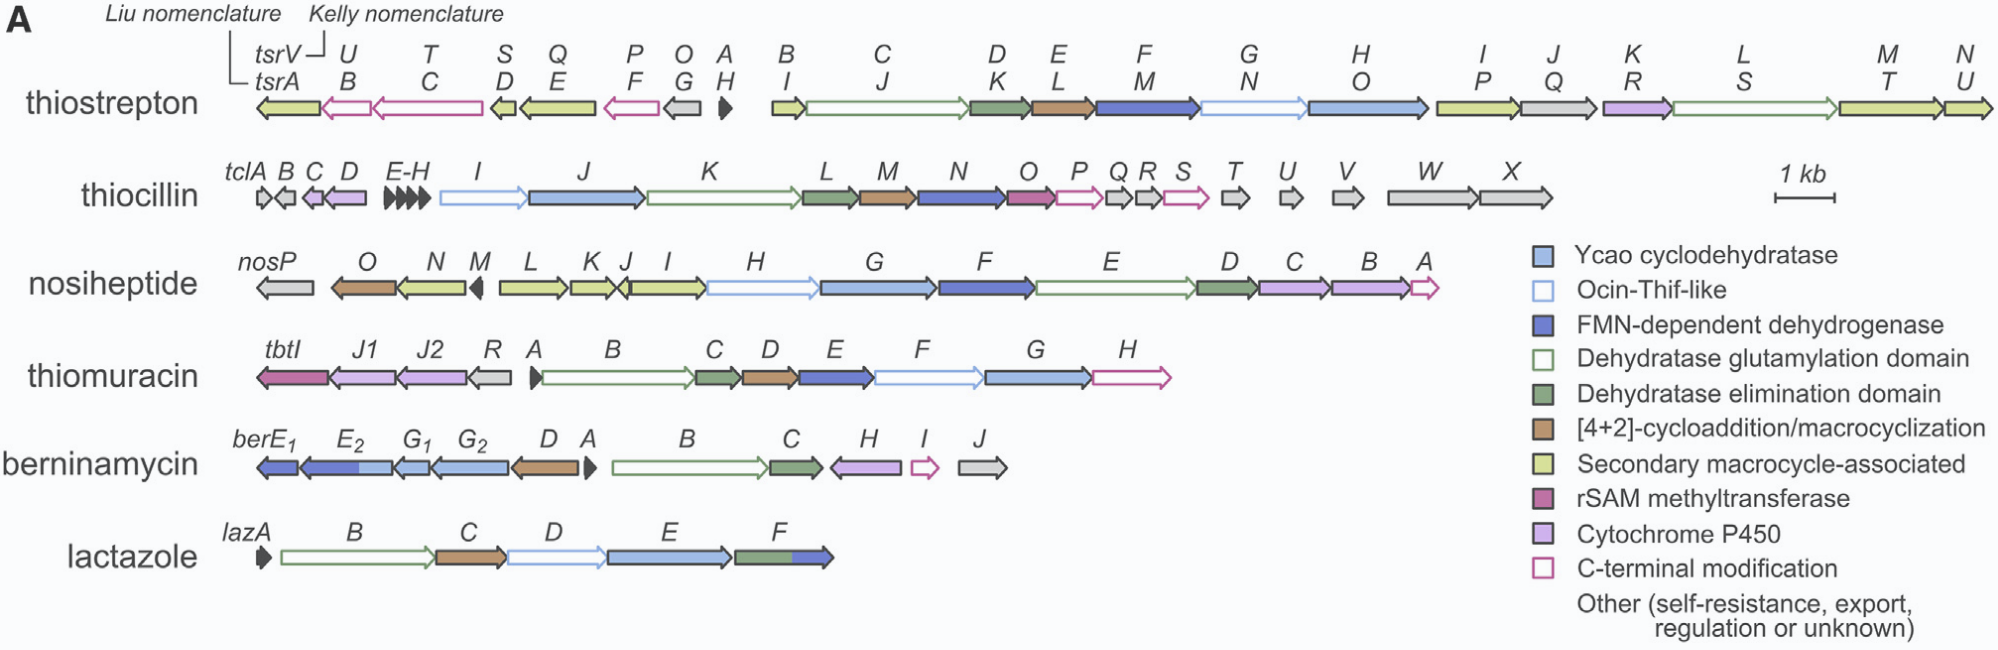
*CGBs de tiopeptidos de distintas series con el nombre de sus proteínas que codifican para la macrociclización y post-traduccionales. Tomado de Vinogradov & Suga, 2020.*

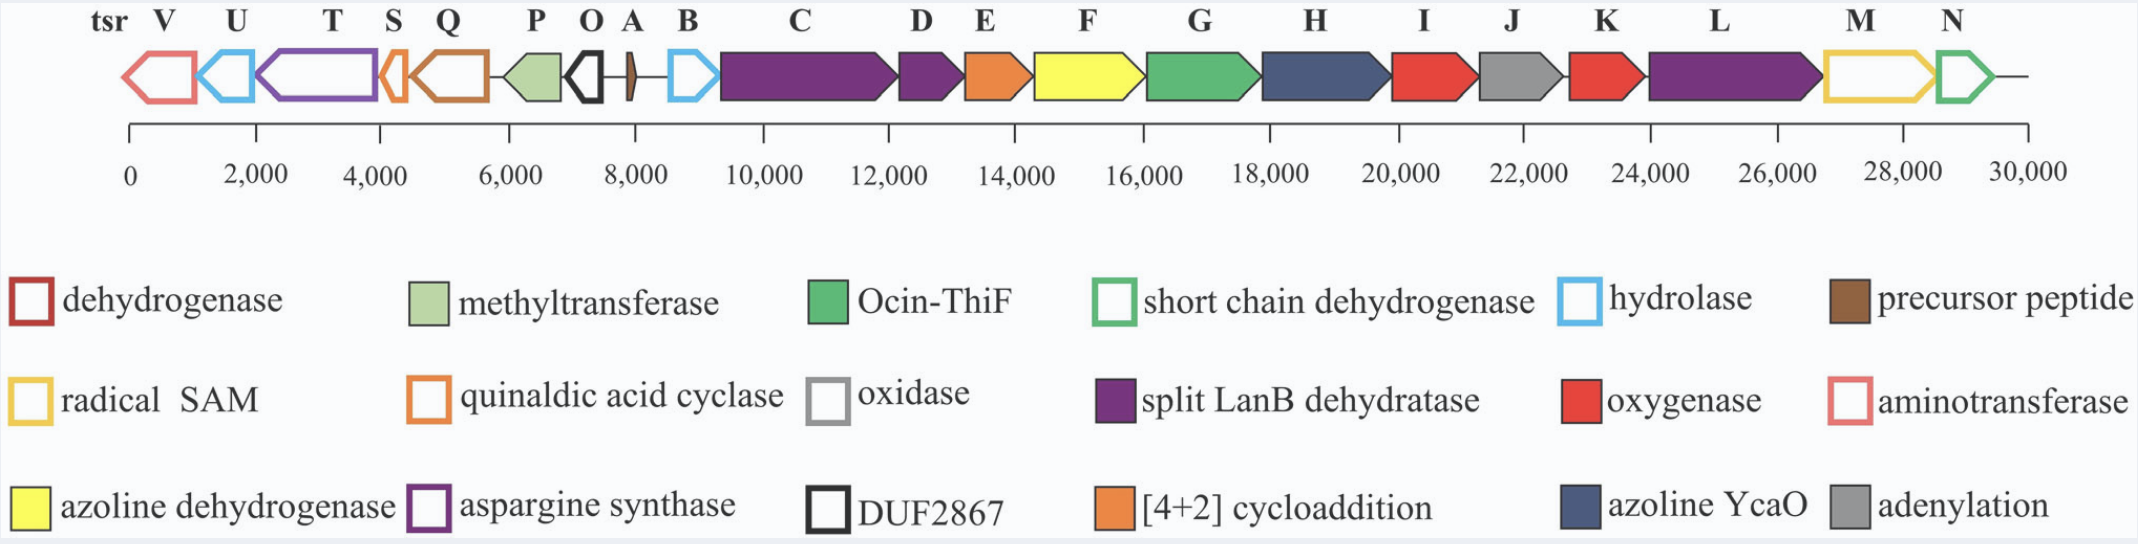
*CGB tiostreptona. Tomado de Aggarwal et al., 2021.*

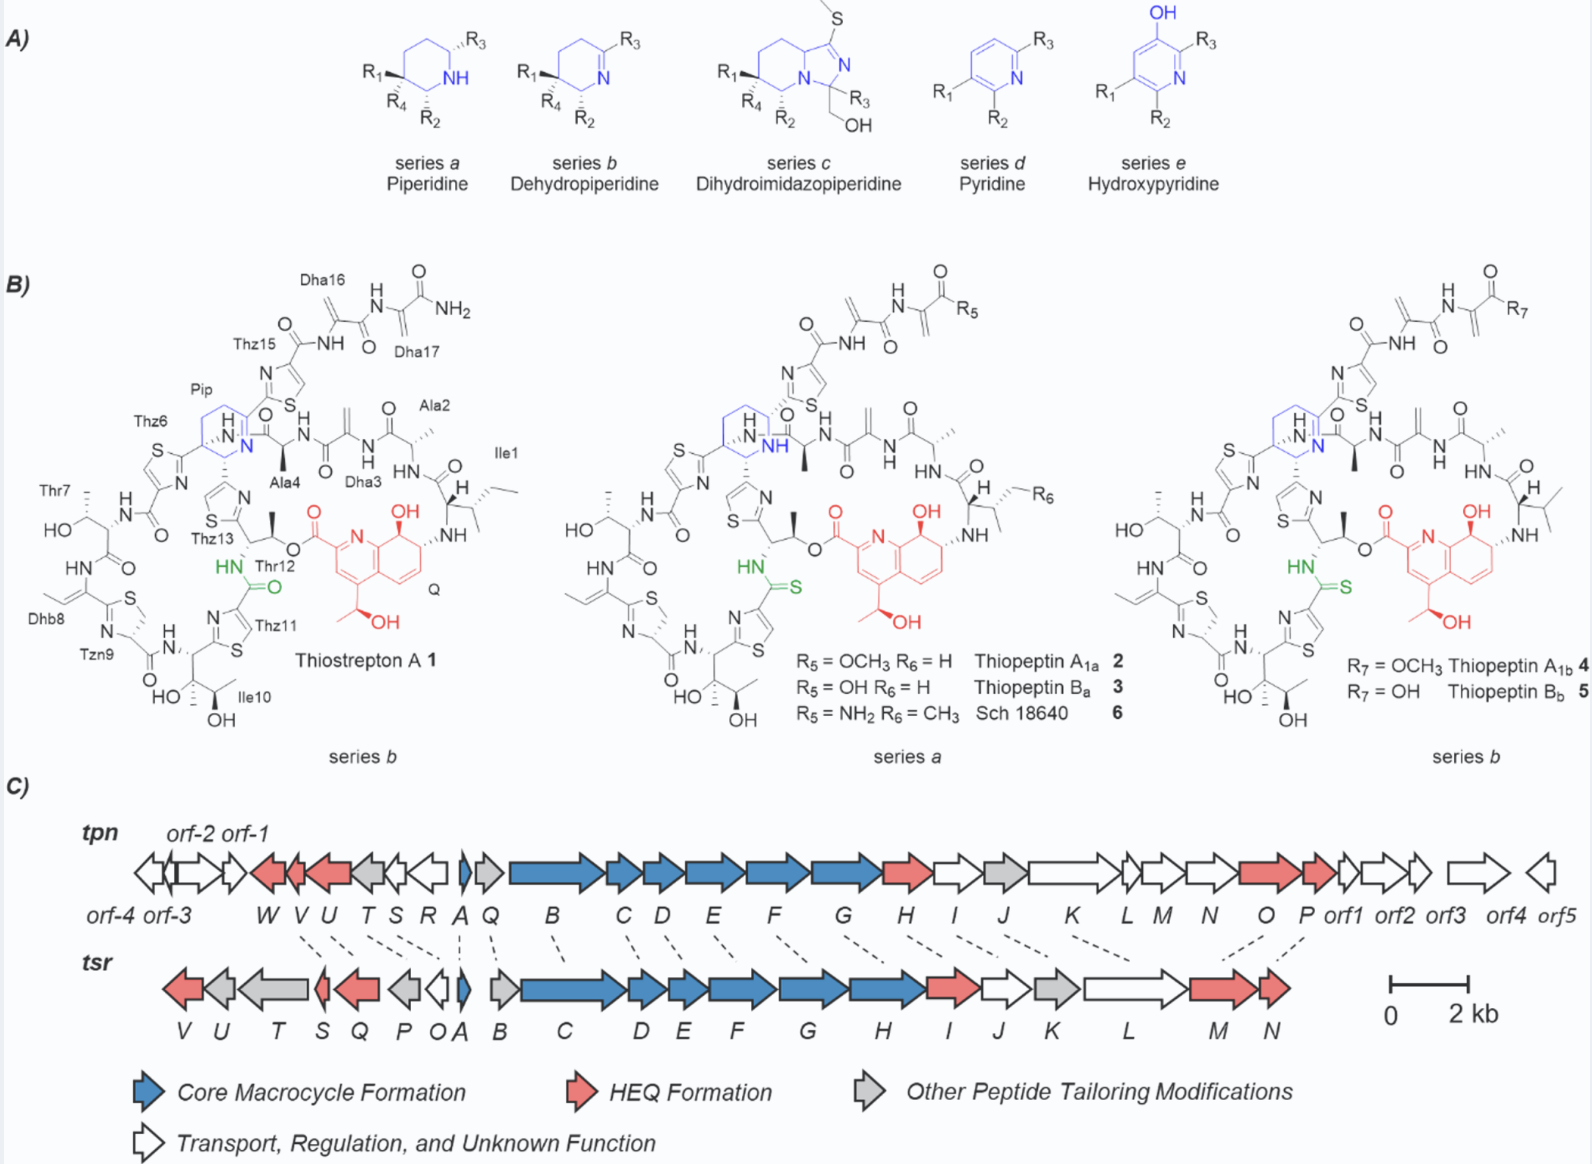
*CGB tiopeptina A1a. (A) Distintas series de tiopéptidos clasificadas de acuerdo al cambio de oxidación en el anillo central. (B) Cambio de serie b a serie a con modificaciones en R y TpnL. (C) CGB de la triosteptona y tiopeptina indicando las posiciones de los genes homólogos con las líneas punteadas. Tomado de Ichikawa et al., 2018.*

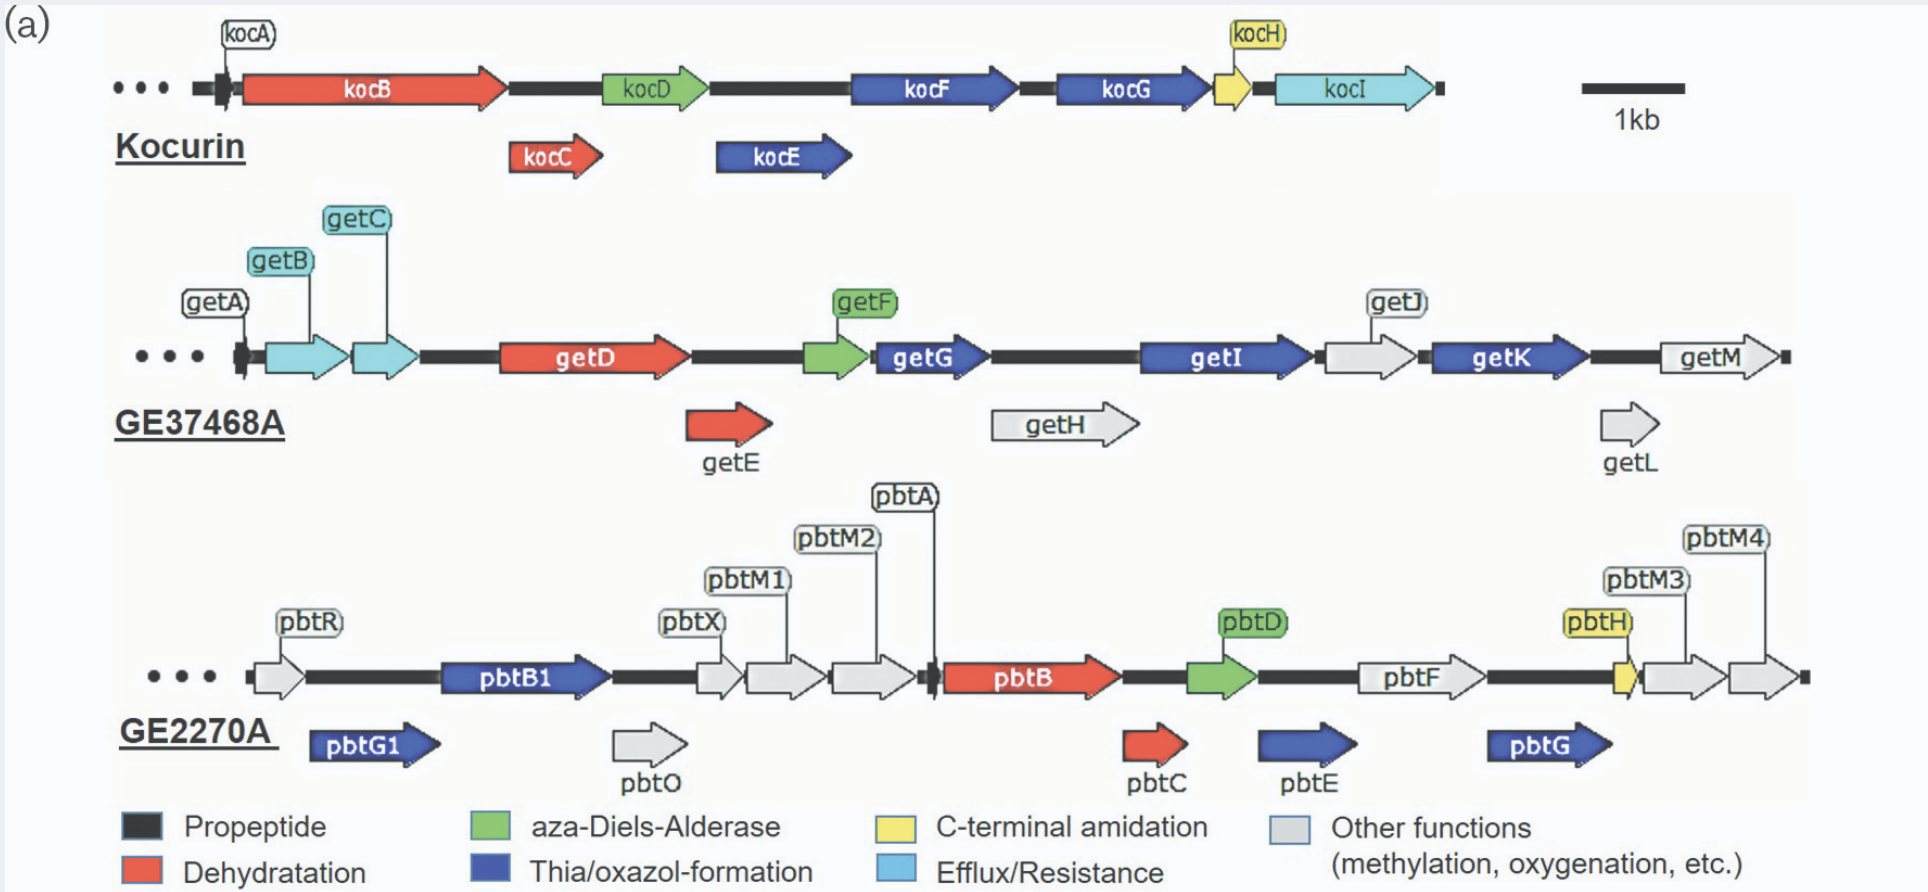
*CGBs de la kocurina y GE2270A con sus genes homólogos. Tomado de Linares-Otoya et al., 2017.*